# Paper figures

## imports

In [24]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from figutils import cm, set_figure_style

set_figure_style()

PAL_MODALITIES = {
    "rna_seq":          "#717EC3",
    "splice_site":      "#AE8799",
    "splice_usage":     "#C95D63",
    "splice_junctions": "#EE8434",
}

PAL_SAMPLES = {
    "WT":    "#C5CBD3",
    "K700E": "#8D6A9F",
}

PAL_MODELS = {
    "AlphaGenome (probing)": "#717EC3",
    "AlphaGenome (LoRA)":    "#4C956C",
    "Pangolin (probing)":    "#EE8434",
    "Pangolin (full)":       "#C95D63",
}

PAL_RESOLUTION = {
    "1bp":  "#717EC3",
    "32bp": "#EE8434",
}

In [25]:
def plot_pearson_bars(data, title, outfile, ylabel="Pearson r", aspect=None, hue=None, palette=None,
                       rotate_value_labels=False):
    col_order    = [SUBSET_LABELS[s] for s in SUBSETS if s in data["subset"].unique()]
    sample_order = list(SAMPLE_LABELS.values())
    has_n = "n" in data.columns
    value_rotation = 90 if rotate_value_labels else 0

    if hue is None and "model" in data.columns:
        hue = "model"
    has_hue = hue is not None
    if has_hue and palette is None:
        palette = PAL_MODELS
    hue_order = list(palette.keys()) if has_hue else None
    if aspect is None:
        aspect = 0.9 if has_hue else 0.6

    g = sns.catplot(
        data=data,
        kind="bar",
        x="sample", y="pearson_r",
        hue=hue if has_hue else None,
        hue_order=hue_order,
        col="subset_label",
        col_order=col_order,
        order=sample_order,
        palette=palette if has_hue else PAL_SAMPLES,
        width=0.6,
        height=4 * cm,
        aspect=aspect,
        legend=has_hue,
        edgecolor="black",
        linewidth=0.5,
    )
    g.set_axis_labels("", ylabel)
    g.set_titles("{col_name}")
    g.set(ylim=(0, 1.05))
    for ax in g.axes.flat:
        subset_label = ax.get_title()
        if has_hue:
            for hue_idx, container in enumerate(ax.containers):
                hue_val = hue_order[hue_idx]
                for bar_idx, bar in enumerate(container):
                    sample = sample_order[bar_idx]
                    h = bar.get_height()
                    cx = bar.get_x() + bar.get_width() / 2
                    ax.text(cx, h + 0.02, "{:.3f}".format(h),
                            ha="center", va="bottom", fontsize=5, rotation=value_rotation)
                    if has_n:
                        row = data[
                            (data["subset_label"] == subset_label)
                            & (data["sample"] == sample)
                            & (data[hue] == hue_val)
                        ]
                        n = int(row["n"].values[0])
                        ax.text(cx, 0.02, "n={:,}".format(n),
                                ha="center", va="bottom", fontsize=4,
                                rotation=90, color="white")
        else:
            for bar_idx, bar in enumerate(ax.patches):
                sample = sample_order[bar_idx]
                h = bar.get_height()
                cx = bar.get_x() + bar.get_width() / 2
                # Pearson r above bar
                ax.text(cx, h + 0.02, "{:.3f}".format(h),
                        ha="center", va="bottom", fontsize=6, rotation=value_rotation)
                # n= rotated vertically at the bottom of the bar
                if has_n:
                    row = data[
                        (data["subset_label"] == subset_label) & (data["sample"] == sample)
                    ]
                    n = int(row["n"].values[0])
                    ax.text(cx, 0.02, "n={:,}".format(n),
                            ha="center", va="bottom", fontsize=5,
                            rotation=90, color="white")
    if has_hue:
        sns.move_legend(g, "center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=5, title=None)
        g.figure.subplots_adjust(right=0.82)
    else:
        plt.tight_layout()
    g.figure.suptitle(title, y=1.04)
    g.figure.savefig(outfile, bbox_inches="tight")
    plt.show()
    print("saved:", outfile)

## data

In [26]:
ROOT     = ".."
EVAL_DIR = os.path.join(ROOT, "results", "bsc", "evaluation", "alphagenome_pytorch", "full")

LORA_EVAL_DIR = os.path.join(ROOT, "results", "evaluation", "alphagenome_pytorch", "full")

PANGOLIN_EVAL_DIR = os.path.join(ROOT, "results", "evaluation", "pangolin", "full")
PANGOLIN_RUN_NAMES = {
    "Pangolin (probing)": "annotated__frozen__1gpu",
    "Pangolin (full)":    "annotated__full__1gpu",
}
PANGOLIN_EPOCH    = 5

OUTPUT_DIR = os.path.join("pdfs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUN_NAME  = "randinit__newloss__annotated__frozen__multigpu_ddp"
EPOCH     = 10
SUBSETS   = ["test", "train_sample"]

# AlphaGenome-only model comparison: linear-probe (frozen backbone) vs LoRA finetuning.
# Both runs were re-evaluated with the same collect_predictions.py version at epochs {1,2,3,4,5,10}.
AG_RUNS = {
    "AlphaGenome (probing)": (EVAL_DIR,      "randinit__newloss__annotated__frozen__multigpu_ddp"),
    "AlphaGenome (LoRA)":    (LORA_EVAL_DIR, "randinit__newloss__annotated__lora__largegpu"),
}

SAMPLE_LABELS = {
    "SRR17111303": "WT",
    "SRR17111311": "K700E",
}

SUBSET_LABELS = {
    "test":         "Test intervals",
    "train_sample": "Train sample",
}

In [27]:
def per_gene_pearson_rows(rna_df, resolution_label):
    rows = []
    for sample_id, sample_label in SAMPLE_LABELS.items():
        sub = rna_df[rna_df["track_name"] == sample_id].dropna(subset=["pred_log_mean", "obs_log_mean"])
        r, _ = stats.pearsonr(sub["obs_log_mean"], sub["pred_log_mean"])
        rows.append({"sample": sample_label, "pearson_r": float(r), "n": len(sub), "resolution": resolution_label})
    return rows


records = []
for model_label, (eval_dir, run_name) in AG_RUNS.items():
    for subset in SUBSETS:
        pred_dir = os.path.join(eval_dir, run_name, "epoch{}".format(EPOCH), subset, "predictions")
        rna_1bp  = pd.read_parquet(os.path.join(pred_dir, "rna_seq_per_gene.parquet"))
        rna_32bp = pd.read_parquet(os.path.join(pred_dir, "rna_seq_per_gene_32bp.parquet"))
        for res_label, rna_df in [("1bp", rna_1bp), ("32bp", rna_32bp)]:
            for row in per_gene_pearson_rows(rna_df, res_label):
                row["subset"] = subset
                row["model"] = model_label
                records.append(row)

metrics = pd.DataFrame(records)
metrics["subset_label"] = metrics["subset"].map(SUBSET_LABELS)
print(metrics)

   sample  pearson_r      n resolution        subset                  model  \
0      WT   0.901071   6631        1bp          test  AlphaGenome (probing)   
1   K700E   0.897334   6631        1bp          test  AlphaGenome (probing)   
2      WT   0.897593   6631       32bp          test  AlphaGenome (probing)   
3   K700E   0.894001   6631       32bp          test  AlphaGenome (probing)   
4      WT   0.958537  46092        1bp  train_sample  AlphaGenome (probing)   
5   K700E   0.953478  46092        1bp  train_sample  AlphaGenome (probing)   
6      WT   0.955774  46092       32bp  train_sample  AlphaGenome (probing)   
7   K700E   0.950871  46092       32bp  train_sample  AlphaGenome (probing)   
8      WT   0.899535   6631        1bp          test     AlphaGenome (LoRA)   
9   K700E   0.896894   6631        1bp          test     AlphaGenome (LoRA)   
10     WT   0.896105   6631       32bp          test     AlphaGenome (LoRA)   
11  K700E   0.893686   6631       32bp          test

## figures

### gene expression — per-gene mean coverage, 1bp vs 32bp, faceted by interval subset

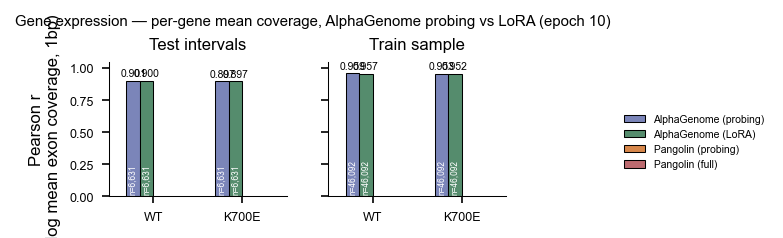

saved: pdfs/gene_expr_pearson_model_epoch10.pdf


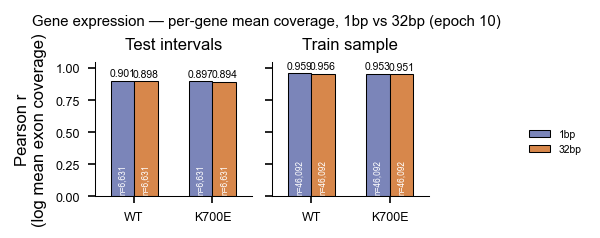

saved: pdfs/gene_expr_pearson_epoch10.pdf


In [28]:
plot_pearson_bars(
    data=metrics[metrics["resolution"] == "1bp"],
    title="Gene expression — per-gene mean coverage, AlphaGenome probing vs LoRA (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "gene_expr_pearson_model_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log mean exon coverage, 1bp)",
    hue="model",
    palette=PAL_MODELS,
)

plot_pearson_bars(
    data=metrics[metrics["model"] == "AlphaGenome (probing)"],
    title="Gene expression — per-gene mean coverage, 1bp vs 32bp (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "gene_expr_pearson_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log mean exon coverage)",
    hue="resolution",
    palette=PAL_RESOLUTION,
)

### gene expression coverage — per-position profile correlation, 1bp vs 32bp, faceted by interval subset

Unlike the per-gene panel above (one Pearson r per gene, computed from its mean exon
coverage), this uses `rna_seq_profile_corr_exon_{1bp,32bp}.parquet` -- Pearson r computed
directly over every log1p(coverage) exon *position* (pooled across all test genes), at
native 1bp resolution vs 32bp-binned (Borzoi-comparable) resolution. Forward/reverse
strand tracks are averaged per sample.

In [29]:
def profile_corr_rows(pred_dir, scope, resolution_label):
    fpath = os.path.join(pred_dir, "rna_seq_profile_corr_{}_{}.parquet".format(scope, resolution_label))
    df = pd.read_parquet(fpath)
    rows = []
    for track_name, sub in df.groupby("track_name"):
        sample_label = SAMPLE_LABELS.get(track_name, track_name)
        rows.append({
            "sample": sample_label,
            "pearson_r": float(sub["pearson_r"].mean()),
            "n": int(sub["n_positions"].sum()),
            "resolution": resolution_label,
        })
    return rows


PROFILE_SCOPES = ["exon", "central"]  # "exon" matches the per-gene exon-mean panel above;
                                       # "central" is the Borzoi-style central crop (also new); "full" is also available

records = []
for model_label, (eval_dir, run_name) in AG_RUNS.items():
    for subset in SUBSETS:
        pred_dir = os.path.join(eval_dir, run_name, "epoch{}".format(EPOCH), subset, "predictions")
        for scope in PROFILE_SCOPES:
            for res_label in ["1bp", "32bp"]:
                for row in profile_corr_rows(pred_dir, scope, res_label):
                    row["subset"] = subset
                    row["model"] = model_label
                    row["scope"] = scope
                    records.append(row)

profile_metrics = pd.DataFrame(records)
profile_metrics["subset_label"] = profile_metrics["subset"].map(SUBSET_LABELS)
print(profile_metrics)

   sample  pearson_r           n resolution        subset  \
0      WT   0.888376    59491902        1bp          test   
1   K700E   0.887730    59491902        1bp          test   
2      WT   0.890874     2004944       32bp          test   
3   K700E   0.890131     2004944       32bp          test   
4      WT   0.823772  2500460544        1bp          test   
5   K700E   0.814992  2500460544        1bp          test   
6      WT   0.830514    78139392       32bp          test   
7   K700E   0.821702    78139392       32bp          test   
8      WT   0.951018   394175378        1bp  train_sample   
9   K700E   0.947423   394175378        1bp  train_sample   
10     WT   0.952707    13272536       32bp  train_sample   
11  K700E   0.949066    13272536       32bp  train_sample   
12     WT   0.907387  2500460544        1bp  train_sample   
13  K700E   0.901576  2500460544        1bp  train_sample   
14     WT   0.912743    78139392       32bp  train_sample   
15  K700E   0.906797    

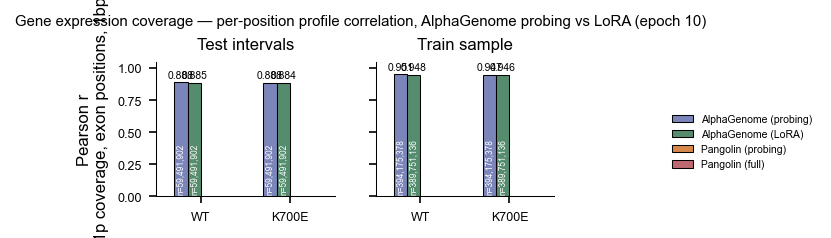

saved: pdfs/gene_expr_profile_corr_model_epoch10.pdf


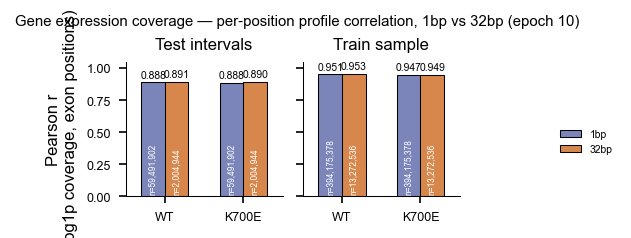

saved: pdfs/gene_expr_profile_corr_epoch10.pdf


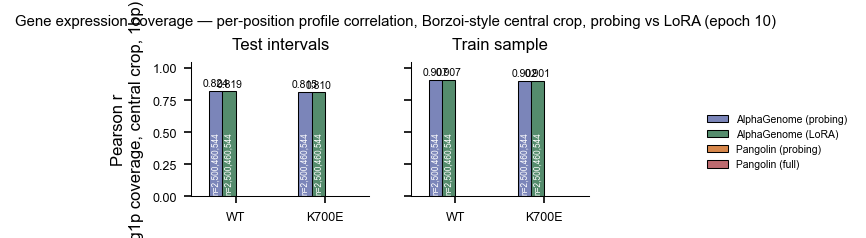

saved: pdfs/gene_expr_profile_corr_central_model_epoch10.pdf


In [30]:
plot_pearson_bars(
    data=profile_metrics[(profile_metrics["scope"] == "exon") & (profile_metrics["resolution"] == "1bp")],
    title="Gene expression coverage — per-position profile correlation, AlphaGenome probing vs LoRA (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "gene_expr_profile_corr_model_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log1p coverage, exon positions, 1bp)",
    hue="model",
    palette=PAL_MODELS,
)

plot_pearson_bars(
    data=profile_metrics[(profile_metrics["scope"] == "exon") & (profile_metrics["model"] == "AlphaGenome (probing)")],
    title="Gene expression coverage — per-position profile correlation, 1bp vs 32bp (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "gene_expr_profile_corr_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log1p coverage, exon positions)",
    hue="resolution",
    palette=PAL_RESOLUTION,
)

plot_pearson_bars(
    data=profile_metrics[(profile_metrics["scope"] == "central") & (profile_metrics["resolution"] == "1bp")],
    title="Gene expression coverage — per-position profile correlation, Borzoi-style central crop, probing vs LoRA (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "gene_expr_profile_corr_central_model_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log1p coverage, central crop, 1bp)",
    hue="model",
    palette=PAL_MODELS,
)

### splice site usage (SSU) — Pearson r by sample, faceted by interval subset

In [31]:
def load_ssu_scores(eval_dir, run_name, epoch, subset, rename_pos=None):
    fpath = os.path.join(eval_dir, run_name, "epoch{}".format(epoch), subset, "predictions", "ssu_scores.parquet")
    df = pd.read_parquet(fpath)
    if rename_pos and rename_pos in df.columns:
        df = df.rename(columns={rename_pos: "exon_pos"})
    return df


def dedup_ssu_mean(df):
    """Collapse duplicate (site, sample) rows created by overlapping test-interval windows.

    test.bed intervals themselves overlap heavily (most consecutive intervals share
    coordinates), so both models emit multiple prediction rows per physical splice
    site -- one per test interval whose context window covers it. Averaging collapses
    each site down to a single row per sample.
    """
    key = ["chrom", "exon_pos", "strand", "sample_id"]
    return df.groupby(key, as_index=False).agg(
        pred_ssu=("pred_ssu", "mean"),
        obs_ssu=("obs_ssu", "mean"),
        alpha_juncs=("alpha_juncs", "max"),
    )


def common_sites(*dfs):
    """Intersection of (chrom, exon_pos, strand) splice sites present in every df."""
    sites = None
    for df in dfs:
        s = set(map(tuple, df[["chrom", "exon_pos", "strand"]].drop_duplicates().values.tolist()))
        sites = s if sites is None else (sites & s)
    return pd.DataFrame(list(sites), columns=["chrom", "exon_pos", "strand"])


def ssu_pearson_rows(df, model_name, chrom_filter=None):
    if chrom_filter is not None:
        df = df[df["chrom"].isin(chrom_filter)]
    rows = []
    for sample_id, sample_label in SAMPLE_LABELS.items():
        grp = df[df["sample_id"] == sample_id].dropna(subset=["pred_ssu", "obs_ssu"])
        r, _ = stats.pearsonr(grp["pred_ssu"].values, grp["obs_ssu"].values)
        rows.append({"sample": sample_label, "pearson_r": float(r), "n": len(grp), "model": model_name})
    return rows

In [32]:
records = []
for subset in SUBSETS:
    ag_dfs = {
        label: load_ssu_scores(eval_dir, run_name, EPOCH, subset, rename_pos="exon_pos_1based")
        for label, (eval_dir, run_name) in AG_RUNS.items()
    }
    pg_dfs = {
        label: load_ssu_scores(PANGOLIN_EVAL_DIR, run_name, PANGOLIN_EPOCH, subset)
        for label, run_name in PANGOLIN_RUN_NAMES.items()
    }

    ag_dedups = {label: dedup_ssu_mean(df) for label, df in ag_dfs.items()}
    pg_dedups = {label: dedup_ssu_mean(df) for label, df in pg_dfs.items()}

    sites = common_sites(*ag_dedups.values(), *pg_dedups.values())
    ag_commons = {
        label: df.merge(sites, on=["chrom", "exon_pos", "strand"], how="inner")
        for label, df in ag_dedups.items()
    }
    pg_commons = {
        label: df.merge(sites, on=["chrom", "exon_pos", "strand"], how="inner")
        for label, df in pg_dedups.items()
    }

    models = list(ag_commons.items()) + list(pg_commons.items())
    for name, d in models:
        for row in ssu_pearson_rows(d, name):
            row["subset"] = subset
            records.append(row)

ssu_metrics = pd.DataFrame(records)
ssu_metrics["subset_label"] = ssu_metrics["subset"].map(SUBSET_LABELS)
print(ssu_metrics)

   sample  pearson_r       n                  model        subset  \
0      WT   0.719248   41821  AlphaGenome (probing)          test   
1   K700E   0.589523   45090  AlphaGenome (probing)          test   
2      WT   0.616662   41821     AlphaGenome (LoRA)          test   
3   K700E   0.539781   45090     AlphaGenome (LoRA)          test   
4      WT   0.590767   41821     Pangolin (probing)          test   
5   K700E   0.447871   45090     Pangolin (probing)          test   
6      WT   0.667583   41821        Pangolin (full)          test   
7   K700E   0.382380   45090        Pangolin (full)          test   
8      WT   0.761439  285953  AlphaGenome (probing)  train_sample   
9   K700E   0.653545  308475  AlphaGenome (probing)  train_sample   
10     WT   0.671938  285953     AlphaGenome (LoRA)  train_sample   
11  K700E   0.617347  308475     AlphaGenome (LoRA)  train_sample   
12     WT   0.594346  285953     Pangolin (probing)  train_sample   
13  K700E   0.424357  308475     P

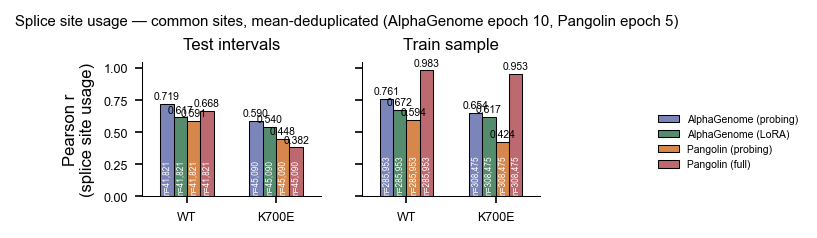

saved: pdfs/ssu_pearson_epoch10.pdf


In [33]:
plot_pearson_bars(
    data=ssu_metrics,
    title="Splice site usage — common sites, mean-deduplicated (AlphaGenome epoch {}, Pangolin epoch {})".format(EPOCH, PANGOLIN_EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "ssu_pearson_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(splice site usage)",
)

### SSU — Pangolin test intervals (unseen chromosomes)

In [34]:
PANGOLIN_UNSEEN_CHROMS = {"chr1", "chr3", "chr5", "chr7", "chr9"}

records = []
for subset in SUBSETS:
    ag_dfs = {
        label: load_ssu_scores(eval_dir, run_name, EPOCH, subset, rename_pos="exon_pos_1based")
        for label, (eval_dir, run_name) in AG_RUNS.items()
    }
    pg_dfs = {
        label: load_ssu_scores(PANGOLIN_EVAL_DIR, run_name, PANGOLIN_EPOCH, subset)
        for label, run_name in PANGOLIN_RUN_NAMES.items()
    }

    ag_dedups = {label: dedup_ssu_mean(df) for label, df in ag_dfs.items()}
    pg_dedups = {label: dedup_ssu_mean(df) for label, df in pg_dfs.items()}

    sites = common_sites(*ag_dedups.values(), *pg_dedups.values())
    ag_commons = {
        label: df.merge(sites, on=["chrom", "exon_pos", "strand"], how="inner")
        for label, df in ag_dedups.items()
    }
    pg_commons = {
        label: df.merge(sites, on=["chrom", "exon_pos", "strand"], how="inner")
        for label, df in pg_dedups.items()
    }

    models = list(ag_commons.items()) + list(pg_commons.items())
    for name, d in models:
        for row in ssu_pearson_rows(d, name, chrom_filter=PANGOLIN_UNSEEN_CHROMS):
            row["subset"] = subset
            records.append(row)

ssu_pangolin_metrics = pd.DataFrame(records)
ssu_pangolin_metrics["subset_label"] = ssu_pangolin_metrics["subset"].map(SUBSET_LABELS)
print(ssu_pangolin_metrics)

   sample  pearson_r      n                  model        subset  \
0      WT   0.758862   9214  AlphaGenome (probing)          test   
1   K700E   0.638949   9926  AlphaGenome (probing)          test   
2      WT   0.645134   9214     AlphaGenome (LoRA)          test   
3   K700E   0.603499   9926     AlphaGenome (LoRA)          test   
4      WT   0.593989   9214     Pangolin (probing)          test   
5   K700E   0.431613   9926     Pangolin (probing)          test   
6      WT   0.684601   9214        Pangolin (full)          test   
7   K700E   0.388950   9926        Pangolin (full)          test   
8      WT   0.759591  84049  AlphaGenome (probing)  train_sample   
9   K700E   0.646736  90903  AlphaGenome (probing)  train_sample   
10     WT   0.673873  84049     AlphaGenome (LoRA)  train_sample   
11  K700E   0.605657  90903     AlphaGenome (LoRA)  train_sample   
12     WT   0.585522  84049     Pangolin (probing)  train_sample   
13  K700E   0.432179  90903     Pangolin (probin

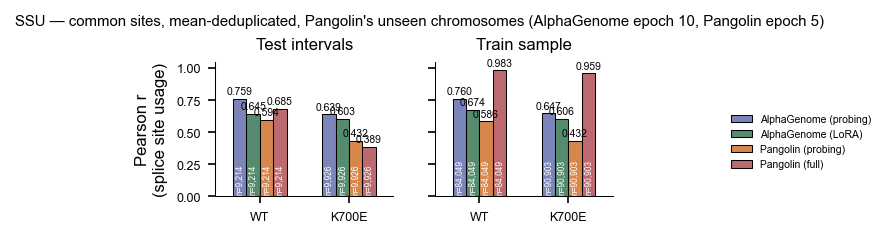

saved: pdfs/ssu_pearson_pangolin_unseen_epoch10.pdf


In [35]:
plot_pearson_bars(
    data=ssu_pangolin_metrics,
    title="SSU — common sites, mean-deduplicated, Pangolin's unseen chromosomes (AlphaGenome epoch {}, Pangolin epoch {})".format(EPOCH, PANGOLIN_EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "ssu_pearson_pangolin_unseen_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(splice site usage)",
)

### junction counts — Pearson r by sample, faceted by interval subset

In [36]:
records = []
for model_label, (eval_dir, run_name) in AG_RUNS.items():
    for subset in SUBSETS:
        pred_dir   = os.path.join(eval_dir, run_name, "epoch{}".format(EPOCH), subset, "predictions")
        metrics_df = pd.read_parquet(os.path.join(eval_dir, run_name, "epoch{}".format(EPOCH), subset, "metrics.parquet"))
        junc_df    = pd.read_parquet(os.path.join(pred_dir, "junction_scores.parquet"))
        for sample_id, sample_label in SAMPLE_LABELS.items():
            r = float(metrics_df.loc[metrics_df["metric_name"] == "junction_count_pearson_r_{}".format(sample_id), "value"].values[0])
            n = int(((junc_df["sample_id"] == sample_id) & (junc_df["obs_count"] > 0)).sum())
            records.append({"subset": subset, "sample": sample_label, "pearson_r": r, "n": n, "model": model_label})

junc_metrics = pd.DataFrame(records)
junc_metrics["subset_label"] = junc_metrics["subset"].map(SUBSET_LABELS)
print(junc_metrics)

         subset sample  pearson_r       n                  model  \
0          test     WT   0.784472  587974  AlphaGenome (probing)   
1          test  K700E   0.791204  641729  AlphaGenome (probing)   
2  train_sample     WT   0.879412  656552  AlphaGenome (probing)   
3  train_sample  K700E   0.879419  717582  AlphaGenome (probing)   
4          test     WT   0.802029  587974     AlphaGenome (LoRA)   
5          test  K700E   0.807280  641729     AlphaGenome (LoRA)   
6  train_sample     WT   0.899980  656552     AlphaGenome (LoRA)   
7  train_sample  K700E   0.900778  717582     AlphaGenome (LoRA)   

     subset_label  
0  Test intervals  
1  Test intervals  
2    Train sample  
3    Train sample  
4  Test intervals  
5  Test intervals  
6    Train sample  
7    Train sample  


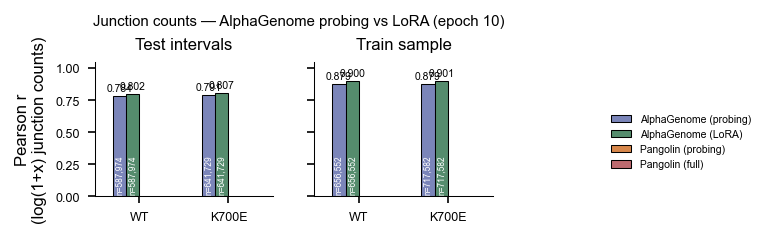

saved: pdfs/junction_count_pearson_epoch10.pdf


In [37]:
plot_pearson_bars(
    data=junc_metrics,
    title="Junction counts — AlphaGenome probing vs LoRA (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "junction_count_pearson_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log(1+x) junction counts)",
)

### junction counts (min observed count >= 5) — filters out lowly-expressed junctions, AlphaGenome probing vs LoRA

         subset sample  pearson_r      n                  model  \
0          test     WT   0.740029  20810  AlphaGenome (probing)   
1          test  K700E   0.736859  23905  AlphaGenome (probing)   
2  train_sample     WT   0.850989  23617  AlphaGenome (probing)   
3  train_sample  K700E   0.842225  27918  AlphaGenome (probing)   
4          test     WT   0.753674  20810     AlphaGenome (LoRA)   
5          test  K700E   0.750333  23905     AlphaGenome (LoRA)   
6  train_sample     WT   0.873851  23617     AlphaGenome (LoRA)   
7  train_sample  K700E   0.867410  27918     AlphaGenome (LoRA)   

     subset_label  
0  Test intervals  
1  Test intervals  
2    Train sample  
3    Train sample  
4  Test intervals  
5  Test intervals  
6    Train sample  
7    Train sample  


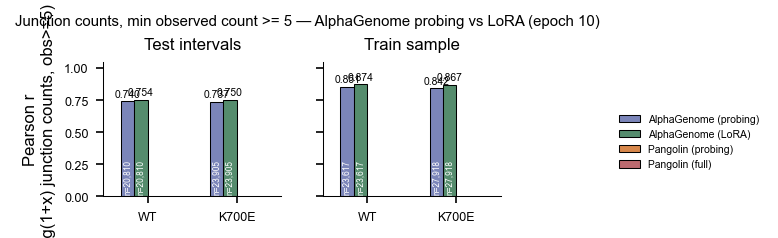

saved: pdfs/junction_count_pearson_mincount5_epoch10.pdf


In [38]:
records = []
for model_label, (eval_dir, run_name) in AG_RUNS.items():
    for subset in SUBSETS:
        metrics_df = pd.read_parquet(os.path.join(eval_dir, run_name, "epoch{}".format(EPOCH), subset, "metrics.parquet"))
        junc_df    = pd.read_parquet(os.path.join(eval_dir, run_name, "epoch{}".format(EPOCH), subset, "predictions", "junction_scores.parquet"))
        for sample_id, sample_label in SAMPLE_LABELS.items():
            r = float(metrics_df.loc[metrics_df["metric_name"] == "junction_count_pearson_r_mincount5_{}".format(sample_id), "value"].values[0])
            n = int(((junc_df["sample_id"] == sample_id) & (junc_df["obs_count"] >= 5)).sum())
            records.append({"subset": subset, "sample": sample_label, "pearson_r": r, "n": n, "model": model_label})

junc_mincount5_metrics = pd.DataFrame(records)
junc_mincount5_metrics["subset_label"] = junc_mincount5_metrics["subset"].map(SUBSET_LABELS)
print(junc_mincount5_metrics)

plot_pearson_bars(
    data=junc_mincount5_metrics,
    title="Junction counts, min observed count >= 5 — AlphaGenome probing vs LoRA (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "junction_count_pearson_mincount5_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log(1+x) junction counts, obs>=5)",
)

### profile-shape metrics — pooled Pearson r, Jensen-Shannon divergence, and total-count Pearson r (AlphaGenome probing vs LoRA)

New metrics from the refactored `collect_predictions.py`, read directly from `metrics.parquet` (already pooled across samples, so there is no per-`sample` split like the panels above):
- `profile_pearson_r_*` — Pearson r computed on raw (non-log) pooled coverage over the whole test interval (`full`) vs the Borzoi-style central crop (`central`)
- `jsd_*` — Jensen-Shannon divergence between predicted and observed coverage *shape* (lower is better, unlike every other panel in this notebook)
- `count_pearson_r_*_track_mean` — Pearson r of per-interval total (summed) coverage, pooled across tracks

In [39]:
def plot_metric_bars(data, value_col, title, outfile, ylabel, hue="model", palette=None, ylim=None):
    hue_order = list(palette.keys()) if palette else None
    order = list(SUBSET_LABELS.values())

    g = sns.catplot(
        data=data,
        kind="bar",
        x="subset_label", y=value_col,
        hue=hue,
        hue_order=hue_order,
        order=order,
        palette=palette,
        width=0.6,
        height=4 * cm,
        aspect=0.9,
        legend=True,
    )
    g.set_axis_labels("", ylabel)
    if ylim is not None:
        g.set(ylim=ylim)
    for ax in g.axes.flat:
        for hue_idx, container in enumerate(ax.containers):
            for bar in container:
                h = bar.get_height()
                cx = bar.get_x() + bar.get_width() / 2
                va = "bottom" if h >= 0 else "top"
                offset = 0.01 * (1 if h >= 0 else -1)
                ax.text(cx, h + offset, "{:.3f}".format(h), ha="center", va=va, fontsize=6)
    sns.move_legend(g, "center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=5, title=None)
    g.figure.subplots_adjust(right=0.78)
    g.figure.suptitle(title, y=1.06)
    g.figure.savefig(outfile, bbox_inches="tight")
    plt.show()
    print("saved:", outfile)


METRIC_NAMES = {
    "profile_pearson_r_full":    "profile_pearson_r_full_mean",
    "profile_pearson_r_central": "profile_pearson_r_central_mean",
    "jsd_full":                  "jsd_full_mean",
    "jsd_central":                "jsd_central_mean",
    "count_pearson_r_full":      "count_pearson_r_full_track_mean",
    "count_pearson_r_central":   "count_pearson_r_central_track_mean",
}

records = []
for model_label, (eval_dir, run_name) in AG_RUNS.items():
    for subset in SUBSETS:
        metrics_df = pd.read_parquet(os.path.join(eval_dir, run_name, "epoch{}".format(EPOCH), subset, "metrics.parquet"))
        row = {"model": model_label, "subset": subset}
        for col_name, metric_name in METRIC_NAMES.items():
            row[col_name] = float(metrics_df.loc[metrics_df["metric_name"] == metric_name, "value"].values[0])
        records.append(row)

profile_shape_metrics = pd.DataFrame(records)
profile_shape_metrics["subset_label"] = profile_shape_metrics["subset"].map(SUBSET_LABELS)
print(profile_shape_metrics)

                   model        subset  profile_pearson_r_full  \
0  AlphaGenome (probing)          test                0.665932   
1  AlphaGenome (probing)  train_sample                0.732670   
2     AlphaGenome (LoRA)          test                0.657503   
3     AlphaGenome (LoRA)  train_sample                0.731942   

   profile_pearson_r_central  jsd_full  jsd_central  count_pearson_r_full  \
0                   0.505114  0.267133     0.352564              0.857692   
1                   0.573088  0.223821     0.321320              0.899918   
2                   0.500127  0.271241     0.354275              0.838953   
3                   0.569989  0.224665     0.322380              0.871383   

   count_pearson_r_central    subset_label  
0                 0.846141  Test intervals  
1                 0.895127    Train sample  
2                 0.824546  Test intervals  
3                 0.859124    Train sample  


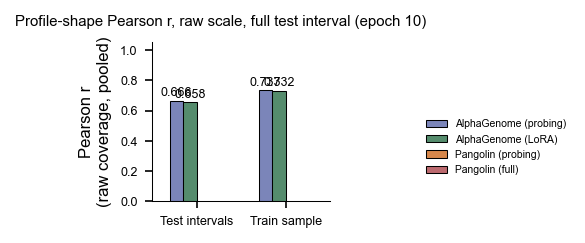

saved: pdfs/profile_pearson_r_full_epoch10.pdf


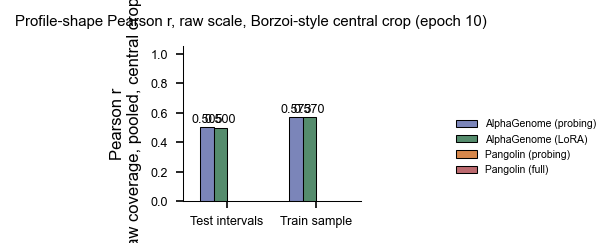

saved: pdfs/profile_pearson_r_central_epoch10.pdf


In [40]:
plot_metric_bars(
    data=profile_shape_metrics,
    value_col="profile_pearson_r_full",
    title="Profile-shape Pearson r, raw scale, full test interval (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "profile_pearson_r_full_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(raw coverage, pooled)",
    palette=PAL_MODELS,
    ylim=(0, 1.05),
)

plot_metric_bars(
    data=profile_shape_metrics,
    value_col="profile_pearson_r_central",
    title="Profile-shape Pearson r, raw scale, Borzoi-style central crop (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "profile_pearson_r_central_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(raw coverage, pooled, central crop)",
    palette=PAL_MODELS,
    ylim=(0, 1.05),
)

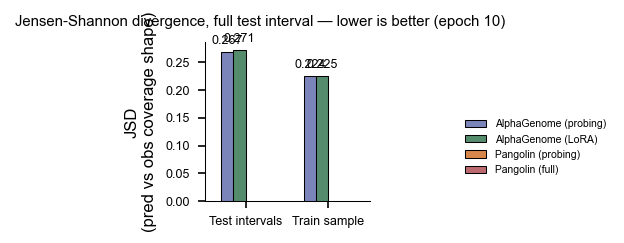

saved: pdfs/jsd_full_epoch10.pdf


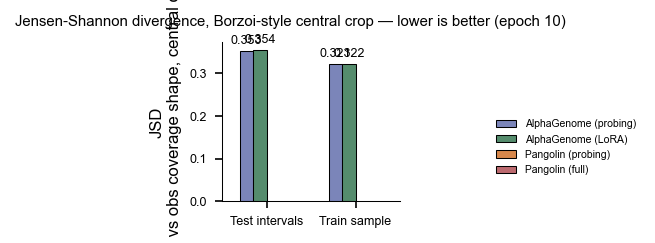

saved: pdfs/jsd_central_epoch10.pdf


In [41]:
plot_metric_bars(
    data=profile_shape_metrics,
    value_col="jsd_full",
    title="Jensen-Shannon divergence, full test interval — lower is better (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "jsd_full_epoch{}.pdf".format(EPOCH)),
    ylabel="JSD\n(pred vs obs coverage shape)",
    palette=PAL_MODELS,
)

plot_metric_bars(
    data=profile_shape_metrics,
    value_col="jsd_central",
    title="Jensen-Shannon divergence, Borzoi-style central crop — lower is better (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "jsd_central_epoch{}.pdf".format(EPOCH)),
    ylabel="JSD\n(pred vs obs coverage shape, central crop)",
    palette=PAL_MODELS,
)

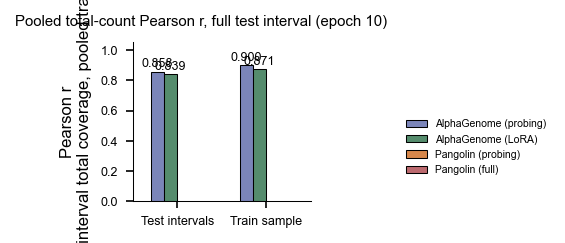

saved: pdfs/count_pearson_r_full_epoch10.pdf


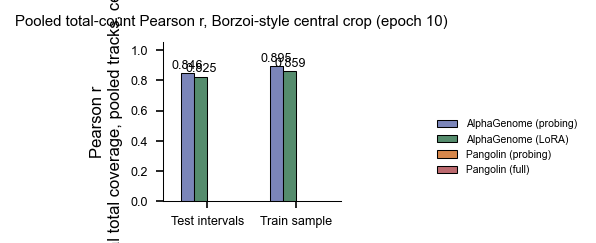

saved: pdfs/count_pearson_r_central_epoch10.pdf


In [42]:
plot_metric_bars(
    data=profile_shape_metrics,
    value_col="count_pearson_r_full",
    title="Pooled total-count Pearson r, full test interval (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "count_pearson_r_full_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(per-interval total coverage, pooled tracks)",
    palette=PAL_MODELS,
    ylim=(0, 1.05),
)

plot_metric_bars(
    data=profile_shape_metrics,
    value_col="count_pearson_r_central",
    title="Pooled total-count Pearson r, Borzoi-style central crop (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "count_pearson_r_central_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(per-interval total coverage, pooled tracks, central crop)",
    palette=PAL_MODELS,
    ylim=(0, 1.05),
)

## publication figures — model comparison across modalities

One bar plot per modality, test intervals only, comparing all four models: AlphaGenome (probing),
AlphaGenome (LoRA), Pangolin (probing), Pangolin (full). AlphaGenome checkpoints are taken at epoch 10
(`EPOCH`), Pangolin at epoch 5 (`PANGOLIN_EPOCH`). Reuses the dataframes already built above
(`profile_metrics`, `ssu_metrics`, `junc_metrics`), filtered down to the test-intervals subset.

- **RNA** — per-position profile correlation, Borzoi-style central crop (`profile_metrics`, `scope="central"`).
  Pangolin does not predict RNA-seq coverage, so this panel is AlphaGenome-only.
- **SSU** — splice site usage correlation restricted to sites common to all four models' test predictions (`ssu_metrics`).
- **Splice junctions** — junction count correlation (`junc_metrics`). Pangolin does not predict junction
  counts, so this panel is also AlphaGenome-only.

### RNA — profile correlation, central crop, test intervals

Uses `rna_seq_profile_corr_per_interval.parquet` (`pearson_r_central_{resolution}`, one row per
interval x track x strand) and averages the **per-interval** Pearson r across test intervals and
strands, per sample -- not the pooled/cumulative Pearson r over all positions concatenated together
(that pooled version is what the earlier "gene expression coverage" section above uses, from
`rna_seq_profile_corr_central_{resolution}.parquet`, and it's dominated by whichever intervals happen
to have the most positions/variance). Averaging per-interval r's instead weights every test interval
equally, which is the right statistic for a model-comparison figure. `n` here is the number of
(interval, strand) values averaged (after dropping intervals/strands with undefined correlation,
e.g. zero-variance signal), not a position count.

  sample  pearson_r     n resolution subset                  model  \
0     WT   0.513791  7989        1bp   test  AlphaGenome (probing)   
1  K700E   0.470890  8844        1bp   test  AlphaGenome (probing)   
2     WT   0.510782  7989        1bp   test     AlphaGenome (LoRA)   
3  K700E   0.468941  8844        1bp   test     AlphaGenome (LoRA)   

     subset_label  
0  Test intervals  
1  Test intervals  
2  Test intervals  
3  Test intervals  


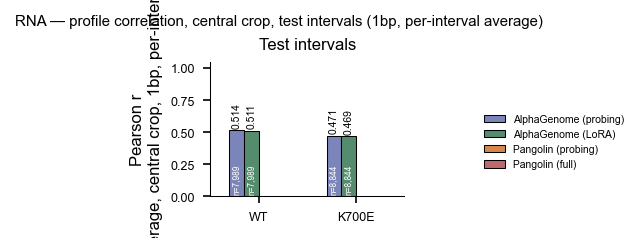

saved: pdfs/pub_rna_profile_corr_central_1bp.pdf


In [46]:
def profile_corr_rows_per_interval(pred_dir, resolution_label):
    fpath = os.path.join(pred_dir, "rna_seq_profile_corr_per_interval.parquet")
    df = pd.read_parquet(fpath)
    col = "pearson_r_central_{}".format(resolution_label)
    rows = []
    for track_name, sub in df.groupby("track_name"):
        sample_label = SAMPLE_LABELS.get(track_name, track_name)
        valid = sub[col].dropna()
        rows.append({
            "sample": sample_label,
            "pearson_r": float(valid.mean()),
            "n": int(len(valid)),
            "resolution": resolution_label,
        })
    return rows


# Resolution for the central-crop RNA profile-correlation panel; switch to "32bp" for the
# Borzoi-comparable binning instead of native 1bp.
PUB_RNA_RESOLUTION = "1bp"

records = []
for model_label, (eval_dir, run_name) in AG_RUNS.items():
    pred_dir = os.path.join(eval_dir, run_name, "epoch{}".format(EPOCH), "test", "predictions")
    for row in profile_corr_rows_per_interval(pred_dir, PUB_RNA_RESOLUTION):
        row["subset"] = "test"
        row["model"] = model_label
        records.append(row)

pub_rna_metrics = pd.DataFrame(records)
pub_rna_metrics["subset_label"] = pub_rna_metrics["subset"].map(SUBSET_LABELS)
print(pub_rna_metrics)

plot_pearson_bars(
    data=pub_rna_metrics,
    title="RNA — profile correlation, central crop, test intervals ({}, per-interval average)".format(PUB_RNA_RESOLUTION),
    outfile=os.path.join(OUTPUT_DIR, "pub_rna_profile_corr_central_{}.pdf".format(PUB_RNA_RESOLUTION)),
    ylabel="Pearson r\n(log1p coverage, central crop, {}, per-interval avg)".format(PUB_RNA_RESOLUTION),
    hue="model",
    palette=PAL_MODELS,
    rotate_value_labels=True,
)

  sample  pearson_r     n resolution subset                  model  \
0     WT   0.521697  7989       32bp   test  AlphaGenome (probing)   
1  K700E   0.477992  8844       32bp   test  AlphaGenome (probing)   
2     WT   0.518747  7989       32bp   test     AlphaGenome (LoRA)   
3  K700E   0.476164  8844       32bp   test     AlphaGenome (LoRA)   

     subset_label  
0  Test intervals  
1  Test intervals  
2  Test intervals  
3  Test intervals  


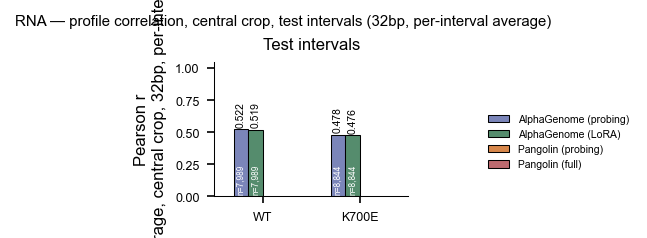

saved: pdfs/pub_rna_profile_corr_central_32bp.pdf


In [47]:
records = []
for model_label, (eval_dir, run_name) in AG_RUNS.items():
    pred_dir = os.path.join(eval_dir, run_name, "epoch{}".format(EPOCH), "test", "predictions")
    for row in profile_corr_rows_per_interval(pred_dir, "32bp"):
        row["subset"] = "test"
        row["model"] = model_label
        records.append(row)

pub_rna_metrics_32bp = pd.DataFrame(records)
pub_rna_metrics_32bp["subset_label"] = pub_rna_metrics_32bp["subset"].map(SUBSET_LABELS)
print(pub_rna_metrics_32bp)

plot_pearson_bars(
    data=pub_rna_metrics_32bp,
    title="RNA — profile correlation, central crop, test intervals (32bp, per-interval average)",
    outfile=os.path.join(OUTPUT_DIR, "pub_rna_profile_corr_central_32bp.pdf"),
    ylabel="Pearson r\n(log1p coverage, central crop, 32bp, per-interval avg)",
    hue="model",
    palette=PAL_MODELS,
    rotate_value_labels=True,
)

### gene-level mean coverage correlation, test intervals

One Pearson r per gene (its mean exon coverage), reusing `metrics` from the "gene expression"
section above (`rna_seq_per_gene.parquet` / `rna_seq_per_gene_32bp.parquet`), filtered to test
intervals.

  sample  pearson_r     n resolution subset                  model  \
0     WT   0.901071  6631        1bp   test  AlphaGenome (probing)   
1  K700E   0.897334  6631        1bp   test  AlphaGenome (probing)   
8     WT   0.899535  6631        1bp   test     AlphaGenome (LoRA)   
9  K700E   0.896894  6631        1bp   test     AlphaGenome (LoRA)   

     subset_label  
0  Test intervals  
1  Test intervals  
8  Test intervals  
9  Test intervals  


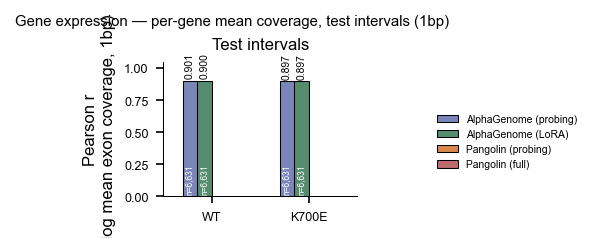

saved: pdfs/pub_gene_expr_pearson_1bp_test.pdf


In [48]:
pub_gene_metrics_1bp = metrics[(metrics["resolution"] == "1bp") & (metrics["subset"] == "test")]
print(pub_gene_metrics_1bp)

plot_pearson_bars(
    data=pub_gene_metrics_1bp,
    title="Gene expression — per-gene mean coverage, test intervals (1bp)",
    outfile=os.path.join(OUTPUT_DIR, "pub_gene_expr_pearson_1bp_test.pdf"),
    ylabel="Pearson r\n(log mean exon coverage, 1bp)",
    hue="model",
    palette=PAL_MODELS,
    rotate_value_labels=True,
)

   sample  pearson_r     n resolution subset                  model  \
2      WT   0.897593  6631       32bp   test  AlphaGenome (probing)   
3   K700E   0.894001  6631       32bp   test  AlphaGenome (probing)   
10     WT   0.896105  6631       32bp   test     AlphaGenome (LoRA)   
11  K700E   0.893686  6631       32bp   test     AlphaGenome (LoRA)   

      subset_label  
2   Test intervals  
3   Test intervals  
10  Test intervals  
11  Test intervals  


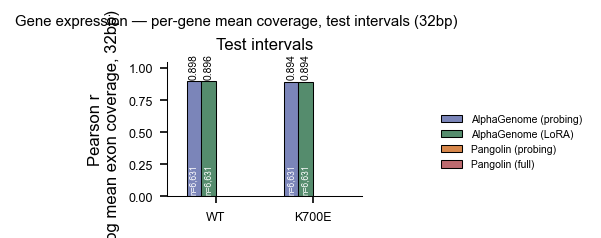

saved: pdfs/pub_gene_expr_pearson_32bp_test.pdf


In [49]:
pub_gene_metrics_32bp = metrics[(metrics["resolution"] == "32bp") & (metrics["subset"] == "test")]
print(pub_gene_metrics_32bp)

plot_pearson_bars(
    data=pub_gene_metrics_32bp,
    title="Gene expression — per-gene mean coverage, test intervals (32bp)",
    outfile=os.path.join(OUTPUT_DIR, "pub_gene_expr_pearson_32bp_test.pdf"),
    ylabel="Pearson r\n(log mean exon coverage, 32bp)",
    hue="model",
    palette=PAL_MODELS,
    rotate_value_labels=True,
)

### SSU — common sites across all four models, test intervals

  sample  pearson_r      n                  model subset    subset_label
0     WT   0.719248  41821  AlphaGenome (probing)   test  Test intervals
1  K700E   0.589523  45090  AlphaGenome (probing)   test  Test intervals
2     WT   0.616662  41821     AlphaGenome (LoRA)   test  Test intervals
3  K700E   0.539781  45090     AlphaGenome (LoRA)   test  Test intervals
4     WT   0.590767  41821     Pangolin (probing)   test  Test intervals
5  K700E   0.447871  45090     Pangolin (probing)   test  Test intervals
6     WT   0.667583  41821        Pangolin (full)   test  Test intervals
7  K700E   0.382380  45090        Pangolin (full)   test  Test intervals


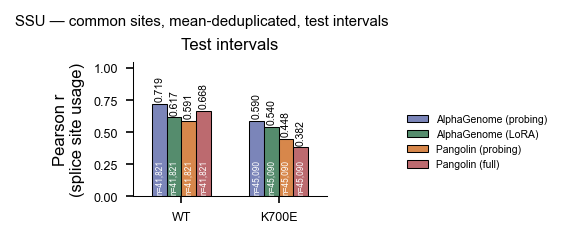

saved: pdfs/pub_ssu_pearson_test.pdf


In [44]:
pub_ssu_metrics = ssu_metrics[ssu_metrics["subset"] == "test"]
print(pub_ssu_metrics)

plot_pearson_bars(
    data=pub_ssu_metrics,
    title="SSU — common sites, mean-deduplicated, test intervals",
    outfile=os.path.join(OUTPUT_DIR, "pub_ssu_pearson_test.pdf"),
    ylabel="Pearson r\n(splice site usage)",
    hue="model",
    palette=PAL_MODELS,
    rotate_value_labels=True,
)

### splice junction counts — test intervals

  subset sample  pearson_r       n                  model    subset_label
0   test     WT   0.784472  587974  AlphaGenome (probing)  Test intervals
1   test  K700E   0.791204  641729  AlphaGenome (probing)  Test intervals
4   test     WT   0.802029  587974     AlphaGenome (LoRA)  Test intervals
5   test  K700E   0.807280  641729     AlphaGenome (LoRA)  Test intervals


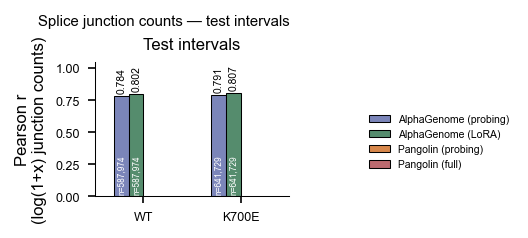

saved: pdfs/pub_junction_count_pearson_test.pdf


In [45]:
pub_junc_metrics = junc_metrics[junc_metrics["subset"] == "test"]
print(pub_junc_metrics)

plot_pearson_bars(
    data=pub_junc_metrics,
    title="Splice junction counts — test intervals",
    outfile=os.path.join(OUTPUT_DIR, "pub_junction_count_pearson_test.pdf"),
    ylabel="Pearson r\n(log(1+x) junction counts)",
    hue="model",
    palette=PAL_MODELS,
    rotate_value_labels=True,
)